## Statistical Hypothesis Testing

---
## Step 1 - Imports & Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy import stats
from statsmodels.stats.multitest import multipletests
from statsmodels.stats.power import TTestIndPower
import warnings

warnings.filterwarnings('ignore')
%matplotlib inline

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100

TITLE_TEAMS = ['Arsenal', 'Liverpool', 'Manchester City', 'Manchester United']

TEAM_PALETTE = {
    'Arsenal':            '#EF0107',
    'Liverpool':          '#00B2A9',
    'Manchester City':    '#6CABDD',
    'Manchester United':  '#FFB81C',
}

rng = np.random.default_rng(42)

print('Imports ready')

Imports ready


---
## Step 2 - Load Data

In [2]:
NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent
PROC_DATA_DIR = PROJECT_ROOT / 'data' / 'processed'

df = pd.read_csv(PROC_DATA_DIR / 'all_4teams_processed.csv')
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values(['team', 'date']).reset_index(drop=True)

print(f'Shape: {df.shape}')
print(f'Teams: {sorted(df["team"].unique())}')

Shape: (1064, 37)
Teams: ['Arsenal', 'Liverpool', 'Manchester City', 'Manchester United']


---
## Section A - Normality Checks

Checks whether points, xG, and match_drop_index look normally distributed. That decides which tests below need a non-parametric companion alongside the standard one.

In [3]:
# Shapiro-Wilk on points, xG, and match_drop_index
# decides which tests get a non-parametric companion later
ars = df[df['team'] == 'Arsenal'].copy()
season_xga_avg = ars.groupby('season')['xGA'].transform('mean')
season_xg_avg = ars.groupby('season')['xG'].transform('mean')
ars['match_drop_index'] = ((season_xg_avg - ars['xG']) + (ars['xGA'] - season_xga_avg)) / 2

for label, series in [('points (0/1/3, discrete)', ars['points']),
                     ('xG', ars['xG']),
                     ('match_drop_index', ars['match_drop_index'])]:
    stat, p = stats.shapiro(series)
    verdict = 'NOT Normal' if p < 0.05 else 'Consistent with Normal'
    print(f'{label:28s} Shapiro-Wilk p={p:.4f}  ->  {verdict}')

points (0/1/3, discrete)     Shapiro-Wilk p=0.0000  ->  NOT Normal
xG                           Shapiro-Wilk p=0.0000  ->  NOT Normal
match_drop_index             Shapiro-Wilk p=0.0545  ->  Consistent with Normal


### Reading Section A

points fails badly, expected, it only takes 3 values (0, 1, 3), no bell curve fits that. xG also fails clearly. match_drop_index sits right on the edge (p=0.055), close enough to normal that a t-test isn't unreasonable, but not clean enough to trust blindly. Every test on points or xG/xGA gets a non-parametric companion from here on, match_drop_index is the one genuinely borderline case.

---
## Section B - xG/xGA Asymmetry, Corrected

NB03 found Arsenal's xG flat under pressure (p=0.665) and xGA significantly worse (p=0.031), one planned test. NB04 reran the same test on all four teams and found Manchester United echoing Arsenal almost exactly. Running 8 tests instead of 1 means correcting for multiple comparisons before trusting either result.

In [4]:
# Welch's t-test and Mann-Whitney U, per team, xG and xGA (8 tests)
ttest_rows=[]
mwu_rows = []

for team in TITLE_TEAMS:
    t = df[df['team'] == team]
    hs = t[t['is_high_stakes_retro']]
    nm = t[~t['is_high_stakes_retro']]

    _, p_xg_t = stats.ttest_ind(hs['xG'], nm['xG'], equal_var = False)
    _, p_xga_t = stats.ttest_ind(hs['xGA'], nm['xGA'], equal_var = False)
    ttest_rows.append({'team' : team, 'xG_p' : p_xg_t, 'xGA_p' : p_xga_t})

    _, p_xg_u = stats.mannwhitneyu(hs['xG'], nm['xG'], alternative = 'two-sided')
    _, p_xga_u = stats.mannwhitneyu(hs['xGA'], nm['xGA'], alternative = 'two-sided')
    mwu_rows.append({'team': team, 'xG_p': p_xg_u, 'xGA_p': p_xga_u})

ttest_df = pd.DataFrame(ttest_rows).set_index('team')
mwu_df = pd.DataFrame(mwu_rows).set_index('team')

print("Welch's t-test (parametric):")
print(ttest_df.round(4))
print()
print('Mann-Whitney U (non-parametric):')
print(mwu_df.round(4))

Welch's t-test (parametric):


                     xG_p   xGA_p
team                             
Arsenal            0.6648  0.0309
Liverpool          0.0805  0.5755
Manchester City    0.8425  0.5746
Manchester United  0.2405  0.0325

Mann-Whitney U (non-parametric):
                     xG_p   xGA_p
team                             
Arsenal            0.6360  0.0205
Liverpool          0.1681  0.9416
Manchester City    0.9401  0.4797
Manchester United  0.1530  0.0256


In [5]:
# Bonferroni and Benjamini-Hochberg correction across the 8 tests

def correct_and_show(pvals_dict, method_name):
    labels = list(pvals_dict.keys())
    pvals = list(pvals_dict.values())
    reject_bonf, p_bonf, _, _ = multipletests(pvals, alpha = 0.05, method='bonferroni')
    reject_bh, p_bh, _, _ = multipletests(pvals, alpha=0.05, method='fdr_bh')
    out = pd.DataFrame({
        'raw_p': pvals,
        'bonferroni_p': p_bonf,
        'bonferroni_sig': reject_bonf,
        'bh_p': p_bh,
        'bh_sig': reject_bh,
    }, index=labels)
    print(f'--- {method_name}: corrected across {len(pvals)} tests ---')
    print(out.round(3))
    print()
    return out

ttest_pvals = {}
mwu_pvals = {}
for team in TITLE_TEAMS:
    ttest_pvals[f'{team} xG'] = ttest_df.loc[team, 'xG_p']
    ttest_pvals[f'{team} xGA'] = ttest_df.loc[team, 'xGA_p']
    mwu_pvals[f'{team} xG'] = mwu_df.loc[team, 'xG_p']
    mwu_pvals[f'{team} xGA'] = mwu_df.loc[team, 'xGA_p']

ttest_corrected = correct_and_show(ttest_pvals, "Welch's t-test")
mwu_corrected = correct_and_show(mwu_pvals, 'Mann-Whitney U')

--- Welch's t-test: corrected across 8 tests ---
                       raw_p  bonferroni_p  bonferroni_sig   bh_p  bh_sig
Arsenal xG             0.665         1.000           False  0.760   False
Arsenal xGA            0.031         0.247           False  0.130   False
Liverpool xG           0.081         0.644           False  0.215   False
Liverpool xGA          0.576         1.000           False  0.760   False
Manchester City xG     0.842         1.000           False  0.842   False
Manchester City xGA    0.575         1.000           False  0.760   False
Manchester United xG   0.241         1.000           False  0.481   False
Manchester United xGA  0.032         0.260           False  0.130   False

--- Mann-Whitney U: corrected across 8 tests ---
                       raw_p  bonferroni_p  bonferroni_sig   bh_p  bh_sig
Arsenal xG             0.636         1.000           False  0.848   False
Arsenal xGA            0.020         0.164           False  0.103   False
Liverpool xG 

### Reading Section B

Arsenal's xGA (t-test p=0.031, Mann-Whitney p=0.021) and Manchester United's xGA (t-test p=0.032, Mann-Whitney p=0.026) both look significant alone. Neither survives correcting for 8 tests at once: Arsenal's xGA lands at Bonferroni 0.247 (t-test) or 0.164 (Mann-Whitney), BH 0.130 either way. United's lands at Bonferroni 0.260 or 0.205, BH 0.130. Nothing clears 0.05 once the full family of tests is accounted for.

---
## Section C - Bottle Gap Significance

The core question this whole project has been building toward: is the high-stakes PPG gap from NB03's Chart C5 and NB04's Chart B1 a real effect, or could a random 10 games out of any given season produce a gap this large just by chance.

---
### Match-level permutation test

A tiny worked example first, small enough to check by hand (6 matches, every possible split enumerated), before running the same idea on real seasons with 10,000 random draws instead of all of them.

In [6]:
# permutation test per team-season: resample which 10 of 38 matches are
# "high stakes", 10,000 draws, empirical p-value. Correct across all 28.
toy_points = np.array([3, 1, 0, 3, 1, 3])
toy_hs_idx = [4,5]
observed_gap = toy_points[toy_hs_idx].mean() - toy_points.mean()

print(f'Toy observed gap: {observed_gap:+.3f}')

#Every possible way to choose 2 of the 6 matches as "high stakes"
from itertools import combinations
null_gaps = []
for combo in combinations(range(6), 2):
    gap = toy_points[list(combo)].mean() - toy_points.mean()
    null_gaps.append(gap)

null_gaps = np.array(null_gaps)
p_exact = np.mean(np.abs(null_gaps) >= abs(observed_gap))
print(f'All {len(null_gaps)} possible 2-of-6 splits, gaps: {np.round(null_gaps, 2)}')
print(f'Exact permutation p-value: {p_exact:.3f}')

Toy observed gap: +0.167
All 15 possible 2-of-6 splits, gaps: [ 0.17 -0.33  1.17  0.17  1.17 -1.33  0.17 -0.83  0.17 -0.33 -1.33 -0.33
  0.17  1.17  0.17]
Exact permutation p-value: 1.000


In [7]:
# one PPG gap value per team-season (n=7 per team, n=28 pooled),
# Wilcoxon signed-rank against zero
def permutation_test(team, season, n_perm=10000):
    t = df[(df['team'] == team) & (df['season'] == season)]
    pts = t['points'].values
    n_hs = t['is_high_stakes_retro'].sum()
    observed_gap = t.loc[t['is_high_stakes_retro'], 'points'].mean() - pts.mean()

    idx = np.arange(len(pts))
    null_gaps = np.empty(n_perm)
    for i in range(n_perm):
        sel = rng.choice(idx, size = n_hs, replace = False)
        null_gaps[i] = pts[sel].mean() - pts.mean()

    p = np.mean(np.abs(null_gaps) >= abs(observed_gap))
    return observed_gap, p

SEASONS = [1920,2021,2122,2223,2324,2425,2526]
perm_rows = []
for team in TITLE_TEAMS:
    for season in SEASONS:
        gap, p = permutation_test(team,season)
        perm_rows.append({'team': team, 'season': season, 'gap':gap, 'p_raw':p})

perm_df = pd.DataFrame(perm_rows)
reject_bonf, p_bonf, _, _ = multipletests(perm_df['p_raw'], alpha = 0.05, method = 'bonferroni')
reject_bh, p_bh, _, _ = multipletests(perm_df['p_raw'], alpha=0.05, method='fdr_bh')
perm_df['p_bonf'] = p_bonf
perm_df['p_bh'] = p_bh
perm_df['sig_raw'] = perm_df['p_raw'] < 0.05

print(perm_df.round(3).to_string(index=False))
print()
print(f'Raw p < 0.05: {perm_df["sig_raw"].sum()} / 28')
print(f'Survives Bonferroni: {(p_bonf < 0.05).sum()} / 28')
print(f'Survives BH: {(p_bh < 0.05).sum()} / 28')

             team  season    gap  p_raw  p_bonf  p_bh  sig_raw
          Arsenal    1920  0.226  0.553   1.000 0.804    False
          Arsenal    2021  0.195  0.689   1.000 0.804    False
          Arsenal    2122 -0.616  0.118   1.000 0.707    False
          Arsenal    2223 -0.111  0.742   1.000 0.830    False
          Arsenal    2324  0.158  0.649   1.000 0.804    False
          Arsenal    2425 -0.047  1.000   1.000 1.000    False
          Arsenal    2526  0.163  0.639   1.000 0.804    False
        Liverpool    1920 -0.605  0.027   0.762 0.707     True
        Liverpool    2021  0.184  0.682   1.000 0.804    False
        Liverpool    2122  0.179  0.606   1.000 0.804    False
        Liverpool    2223  0.637  0.080   1.000 0.707    False
        Liverpool    2324 -0.158  0.625   1.000 0.804    False
        Liverpool    2425 -0.511  0.115   1.000 0.707    False
        Liverpool    2526 -0.179  0.689   1.000 0.804    False
  Manchester City    1920 -0.032  1.000   1.000 1.000  

### Reading the permutation results

Only 1 of 28 team-seasons comes in under raw p=0.05, and it is not one of Arsenal's own bottle seasons, it is Liverpool's 2019-20 (p=0.027). None of Arsenal's four headline seasons (22-23, 23-24, 24-25, 25-26) get remotely close, every one sits between p=0.64 and p=1.00. Even Liverpool's one nominal hit does not survive correcting for testing all 28 team-seasons at once (Bonferroni 0.762, BH 0.707).

At the match level, within any single season, none of this project's named bottle seasons produce a high-stakes/normal split more extreme than what a random 10-game subset of that same season would typically produce.

---
### Season-level Wilcoxon signed-rank (avoids pseudoreplication)

The test above has a subtle problem: the 38 matches inside one season aren't fully independent of each other, they share a manager, a squad, a run of form. Zooming out to one PPG gap value per team-season (7 per team, 28 total) and running the paired Wilcoxon signed-rank test on those sidesteps that.

In [8]:
season_ppg = df.groupby(['team', 'season'])['points'].mean()
hs_ppg = df[df['is_high_stakes_retro']].groupby(['team', 'season'])['points'].mean()
gap = (hs_ppg - season_ppg).rename('gap')

w_stat, w_p = stats.wilcoxon(hs_ppg.values, season_ppg.values)
print(f'Pooled Wilcoxon signed-rank, all 28 team-seasons: statistic={w_stat:.1f}  p={w_p:.4f}')
print()

gap_df = gap.reset_index()
for team in TITLE_TEAMS:
    vals = gap_df[gap_df['team'] == team]['gap']
    w_stat, w_p = stats.wilcoxon(vals)
    print(f'{team:20s} n={len(vals)}  median gap={vals.median():+.3f}  Wilcoxon p={w_p:.4f}')

Pooled Wilcoxon signed-rank, all 28 team-seasons: statistic=184.5  p=0.6735

Arsenal              n=7  median gap=+0.158  Wilcoxon p=0.5781
Liverpool            n=7  median gap=-0.158  Wilcoxon p=0.9844
Manchester City      n=7  median gap=+0.153  Wilcoxon p=0.3750
Manchester United    n=7  median gap=+0.153  Wilcoxon p=0.8125


### Reading the Wilcoxon results

Pooled across all 28 team-seasons, p=0.67, nowhere near significant. Broken down by team, every single one sits above p=0.37. By this more conservative, pseudoreplication-safe measure, there is no statistically detectable tendency for any team's high-stakes PPG to differ from its own season baseline, in either direction.

Two different questions, two different answers worth holding onto separately. The permutation test above asks whether one specific season's split was unusual, given exactly what happened that season. This test asks whether there is a consistent pattern across seasons. Both come back null, but for different reasons, one because no single season stands out, the other because whatever small season-to-season swings exist don't add up to a consistent direction.

---
### A structural check: does "high stakes" even track bad results?

Before moving on, worth checking why both tests above came back null rather than just accepting it. Split each season into its best-10, middle-18, and worst-10 results by points, then check where the actual high-stakes matches land across those three groups, against what pure chance would predict.

In [9]:
rows = []
for team in TITLE_TEAMS:
    for season in SEASONS:
        s = df[(df['team'] == team) & (df['season'] == season)].reset_index(drop=True)
        pts = s['points'].values
        n_hs = s['is_high_stakes_retro'].sum()
        actual_idx = set(s.index[s['is_high_stakes_retro']].values)

        sorted_idx = np.argsort(pts, kind='stable')
        worst_idx = set(sorted_idx[:n_hs])
        best_idx = set(sorted_idx[-n_hs:])
        middle_idx = set(range(len(pts))) - worst_idx - best_idx

        rows.append({
            'team': team, 'season': season,
            'overlap_worst': len(actual_idx & worst_idx),
            'overlap_middle': len(actual_idx & middle_idx),
            'overlap_best': len(actual_idx & best_idx),
        })

overlap_df = pd.DataFrame(rows)
print('Average overlap between actual high-stakes matches and each result group, all 28 team-seasons:')
print(f'  worst-10 group:  {overlap_df["overlap_worst"].mean():.2f} / 10   (chance baseline: 2.63)')
print(f'  middle-18 group: {overlap_df["overlap_middle"].mean():.2f} / 10   (chance baseline: 4.74)')
print(f'  best-10 group:   {overlap_df["overlap_best"].mean():.2f} / 10   (chance baseline: 2.63)')

Average overlap between actual high-stakes matches and each result group, all 28 team-seasons:
  worst-10 group:  2.07 / 10   (chance baseline: 2.63)
  middle-18 group: 2.04 / 10   (chance baseline: 4.74)
  best-10 group:   5.89 / 10   (chance baseline: 2.63)


### Reading the overlap check

Overlap with the worst-10 sits right around the chance baseline. Overlap with the middle-18 comes in well below chance, and overlap with the best-10 comes in more than double the chance baseline. High-stakes matches land almost exclusively among a team's best results, almost never among its ordinary ones.

Not a bug in is_high_stakes_retro (re-checked the computation directly, still exactly the top 25% of stakes_intensity per team-season). The cause is mechanical: title_gap can only stay small late in a season if a team has been winning recently, so "this match is high stakes" and "this team has been playing well lately" aren't independent facts, they're mechanically linked through the table. Any true negative pressure effect has to fight a built-in positive bias just to bring a team's high-stakes PPG down to baseline, let alone below it. See decisions_log.md for the fuller writeup, including why this makes Arsenal's small negative gaps in its bottle seasons more notable, not less.

---
## Section D - Cross-Team Comparison

NB04's Pressure Resilience Index ranked the four teams by mean PPG gap: City best, Liverpool worst. This asks a different question than anything above, not whether one team differs from zero, but whether the four teams differ from each other.

In [10]:
groups = [gap_df[gap_df['team'] == team]['gap'].values for team in TITLE_TEAMS]
h_stat, p_kw = stats.kruskal(*groups)

print(f'Kruskal-Wallis H = {h_stat:.3f}, p = {p_kw:.4f}')
print()
print('Group medians:')
for team, g in zip(TITLE_TEAMS, groups):
    print(f'  {team:20s} median gap = {np.median(g):+.3f}')

Kruskal-Wallis H = 0.449, p = 0.9300

Group medians:
  Arsenal              median gap = +0.158
  Liverpool            median gap = -0.158
  Manchester City      median gap = +0.153
  Manchester United    median gap = +0.153


### Reading Chart D1

H=0.449 on 3 degrees of freedom is a very small test statistic, p=0.93 confirms it, essentially no evidence the four teams' gap distributions differ from each other at all. The NB04 ranking (City best, Liverpool worst) is a real ordering of 4 numbers, that's just arithmetic, but statistically the four teams are indistinguishable from each other given this data.

---
## Section E - Bootstrap Confidence Intervals

A p-value answers whether something differs from zero. A confidence interval answers a more useful question: given the uncertainty in a small sample, what's the plausible range for the true value. Resampling each team's own contention-season gaps with replacement, thousands of times, builds one directly.

In [11]:
bucket_counts = (
    df.groupby(['team', 'season', 'is_high_stakes'])
    .size().unstack(fill_value=0)
    .rename(columns={False: 'n_normal', True: 'n_highstakes'})
)
contention = bucket_counts[bucket_counts['n_highstakes'] >= 5].reset_index()[['team', 'season']]
gap_contention = gap_df.merge(contention, on=['team', 'season'], how='inner')

ci_rows = []
for team in TITLE_TEAMS:
    vals = gap_contention[gap_contention['team'] == team]['gap'].values
    n = len(vals)
    boot_means = np.array([rng.choice(vals, size=n, replace=True).mean() for _ in range(10000)])
    lo, hi = np.percentile(boot_means, [2.5, 97.5])
    ci_rows.append({'team': team, 'n': n, 'mean': vals.mean(), 'ci_low': lo, 'ci_high': hi})

ci_df = pd.DataFrame(ci_rows).set_index('team')
print(ci_df.round(3))

                   n   mean  ci_low  ci_high
team                                        
Arsenal            5 -0.091  -0.360    0.119
Liverpool          6 -0.182  -0.428    0.065
Manchester City    7  0.071  -0.132    0.223
Manchester United  5 -0.011  -0.343    0.308


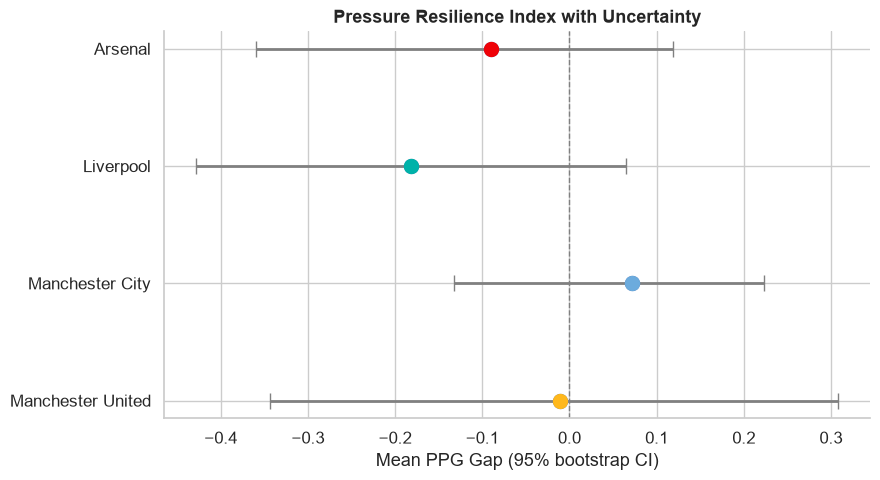

In [12]:
fig, ax = plt.subplots(figsize=(9, 5))

y_pos = np.arange(len(TITLE_TEAMS))
means = [ci_df.loc[t, 'mean'] for t in TITLE_TEAMS]
lo_err = [ci_df.loc[t, 'mean'] - ci_df.loc[t, 'ci_low'] for t in TITLE_TEAMS]
hi_err = [ci_df.loc[t, 'ci_high'] - ci_df.loc[t, 'mean'] for t in TITLE_TEAMS]
colors = [TEAM_PALETTE[t] for t in TITLE_TEAMS]

ax.errorbar(means, y_pos, xerr=[lo_err, hi_err], fmt='o', markersize=10,
            capsize=6, elinewidth=2, ecolor='grey')
for i, (m, c) in enumerate(zip(means, colors)):
    ax.plot(m, i, 'o', markersize=10, color=c, zorder=3)

ax.axvline(x=0, color='grey', linewidth=1, linestyle='--')
ax.set_yticks(y_pos)
ax.set_yticklabels(TITLE_TEAMS)
ax.set_xlabel('Mean PPG Gap (95% bootstrap CI)')
ax.set_title('Pressure Resilience Index with Uncertainty', fontsize=13, fontweight='bold')
ax.invert_yaxis()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

### Reading Chart E1

Every team's 95% interval comfortably contains zero, and every pair of teams overlaps substantially. With 5 to 7 seasons per team, there isn't enough data to pin down these teams' pressure resilience precisely enough to say which one is genuinely better than which other one, the same conclusion as the Kruskal-Wallis test, arrived at visually instead of through a single p-value.

---
## Section F - Effect Size and Statistical Power

Nothing so far has come back significant. Before reading that as "there's no bottle effect," it's worth checking whether these sample sizes could even detect a real effect if one exists. Cohen's d measures effect size on its own terms, independent of sample size; power is the probability a test would actually catch a real effect of a given size, given the sample actually available.

In [13]:
analysis = TTestIndPower()
n_hs, n_normal = 10, 28  # a typical Arsenal high-stakes-retro season split

min_detectable_d = analysis.solve_power(effect_size=None, nobs1=n_hs, ratio=n_normal/n_hs,
                                          alpha=0.05, power=0.8)
print(f'With n={n_hs} high-stakes vs n={n_normal} normal matches, at alpha=0.05,')
print(f'the smallest effect size we could reliably (80% of the time) detect is d={min_detectable_d:.2f}')
print('(0.2=small, 0.5=medium, 0.8=large effect, by convention)')
print()

print('Cohen\'s d actually observed, Arsenal\'s 4 headline seasons (points, high-stakes vs normal):')
for season in [2223, 2324, 2425, 2526]:
    s = ars[ars['season'] == season]
    hs = s[s['is_high_stakes_retro']]['points']
    nm = s[~s['is_high_stakes_retro']]['points']
    pooled_sd = pd.concat([hs, nm]).std()
    d = (hs.mean() - nm.mean()) / pooled_sd
    print(f'  {season}: d = {d:+.3f}')

With n=10 high-stakes vs n=28 normal matches, at alpha=0.05,
the smallest effect size we could reliably (80% of the time) detect is d=1.06
(0.2=small, 0.5=medium, 0.8=large effect, by convention)

Cohen's d actually observed, Arsenal's 4 headline seasons (points, high-stakes vs normal):
  2223: d = -0.124
  2324: d = +0.187
  2425: d = -0.055
  2526: d = +0.189


### Reading Section F

To reliably detect a real effect at these sample sizes needs roughly d=1.06, a genuinely enormous effect by any football standard. What Arsenal's own bottle seasons actually show is d between 0.05 and 0.19, an order of magnitude smaller. "Not statistically significant" here means "not enough data to know," not "proven to be nothing." The honest conclusion isn't that the bottle isn't real, it's that 10 matches a season can't settle it either way, and no amount of cleverer testing changes that, only more seasons would.

---
## Key Findings Summary

In [14]:
print('=' * 70)
print('KEY FINDINGS - Statistical Hypothesis Testing')
print('=' * 70)
print()
print('1. THE XGA ASYMMETRY DOES NOT SURVIVE MULTIPLE-COMPARISONS CORRECTION')
print('   Arsenal xGA p=0.031, Manchester United xGA p=0.032, both significant')
print('   in isolation. Neither survives Bonferroni or BH correction across the')
print('   family of 8 tests (4 teams x xG/xGA). Mann-Whitney U confirms the same')
print('   pattern non-parametrically.')
print()
print('2. THE BOTTLE GAP DOES NOT SURVIVE TESTING, AT EITHER LEVEL')
print('   Match-level permutation: 1 of 28 team-seasons significant at raw')
print('   p<0.05 (Liverpool 19-20), and it does not survive correction either.')
print('   None of Arsenal\'s own 4 headline seasons come close (p > 0.64 each).')
print('   Season-level Wilcoxon (avoiding pseudoreplication): pooled p=0.67,')
print('   every team individually p>0.37.')
print()
print('3. "HIGH STAKES" IS STRUCTURALLY BIASED TOWARD GOOD RESULTS')
print('   High-stakes matches overlap a team\'s own best-10 results more than')
print('   double the pure-chance rate, and its middle-18 results well below')
print('   chance. Mechanical, not a bug: title_gap can only stay small if a')
print('   team keeps winning, so stakes and recent form are entangled. Any')
print('   true negative pressure effect has to fight this built-in bias just')
print('   to bring a team\'s high-stakes PPG down to baseline.')
print()
print('4. THE FOUR TEAMS ARE STATISTICALLY INDISTINGUISHABLE FROM EACH OTHER')
print('   Kruskal-Wallis across the season-level gaps: H=0.449, p=0.930.')
print('   Bootstrap 95% CIs for all 4 teams overlap heavily and all include zero.')
print()
print('5. BUT THIS IS ALSO A SAMPLE SIZE PROBLEM, NOT PROOF OF NO EFFECT')
print('   Detecting a real effect at n=10 vs n=28 needs d=1.06, an enormous')
print('   effect. Observed effects are d=0.05 to 0.19. Small samples cannot')
print('   rule out real, football-sized effects, they can only fail to catch them.')
print()
print('6. HONEST SYNTHESIS')
print('   NB03/NB04 were right to frame everything as directional, not proven.')
print('   That framing holds up. The patterns are consistent with a real,')
print('   modest bottle effect, one working against a metric that is structurally')
print('   biased against finding it, but this data alone cannot confirm one at')
print('   any conventional significance threshold. More seasons, not cleverer')
print('   tests, is what would actually settle it.')
print()
print('Next -> NB06: predictive modelling uses stakes_intensity as a continuous')
print('feature rather than a significance-tested bucket comparison, sidestepping')
print('this exact small-sample problem by letting the model learn from all 1,064')
print('matches at once instead of splitting them into small buckets first.')

KEY FINDINGS - Statistical Hypothesis Testing

1. THE XGA ASYMMETRY DOES NOT SURVIVE MULTIPLE-COMPARISONS CORRECTION
   Arsenal xGA p=0.031, Manchester United xGA p=0.032, both significant
   in isolation. Neither survives Bonferroni or BH correction across the
   family of 8 tests (4 teams x xG/xGA). Mann-Whitney U confirms the same
   pattern non-parametrically.

2. THE BOTTLE GAP DOES NOT SURVIVE TESTING, AT EITHER LEVEL
   Match-level permutation: 1 of 28 team-seasons significant at raw
   p<0.05 (Liverpool 19-20), and it does not survive correction either.
   None of Arsenal's own 4 headline seasons come close (p > 0.64 each).
   Season-level Wilcoxon (avoiding pseudoreplication): pooled p=0.67,
   every team individually p>0.37.

3. "HIGH STAKES" IS STRUCTURALLY BIASED TOWARD GOOD RESULTS
   High-stakes matches overlap a team's own best-10 results more than
   double the pure-chance rate, and its middle-18 results well below
   chance. Mechanical, not a bug: title_gap can only st